# CV for Manufacturing — Dataset Visualisation

This notebook samples and visualises images from the three datasets loaded into
`brian_gen_ai.cv_manufacturing.raw`:

1. **SHWD** — Safety Helmet Wearing Dataset (Pascal VOC)
2. **DeepPCB** — PCB Defect Detection (image pairs + txt annotations)
3. **Corrosion Detection** — Infrastructure corrosion (HuggingFace Parquet)

Volume base path: `/Volumes/brian_gen_ai/cv_manufacturing/raw`

## Setup

In [1]:
import os
import io
import zipfile
import random
import xml.etree.ElementTree as ET
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd

# When running on Databricks, use:
# VOLUME_BASE = "/Volumes/brian_gen_ai/cv_manufacturing/raw"
#
# For local execution, update paths to where the data files are stored.
VOLUME_BASE = "/tmp"

random.seed(42)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. SHWD — Safety Helmet Wearing Dataset

Pascal VOC format with bounding boxes for `hat` (helmet worn) and `person` (no helmet) classes.

- **Source:** [njvisionpower/Safety-Helmet-Wearing-Dataset](https://github.com/njvisionpower/Safety-Helmet-Wearing-Dataset)
- **Licence:** MIT
- **Size:** 7,581 images

Total images: 7571
Total annotations: 7581


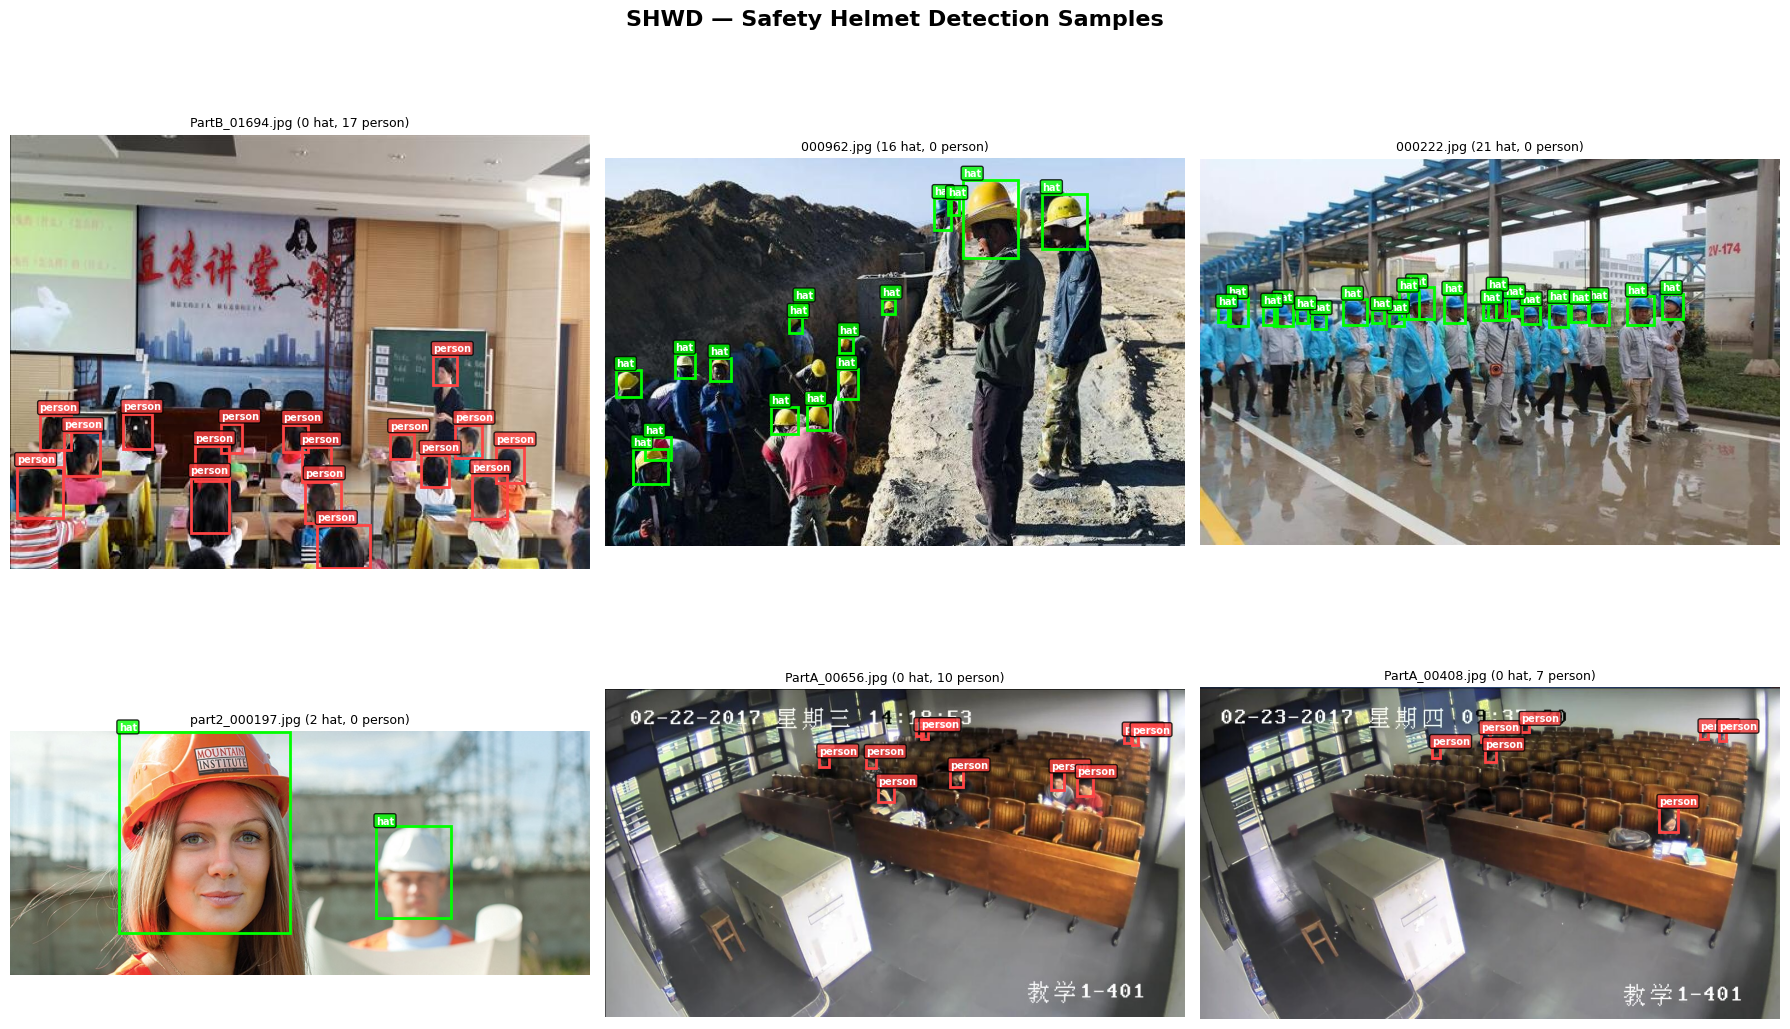


Legend: Green = hat (helmet), Red = person (no helmet)


In [2]:
# Read images and annotations from the SHWD zip
shwd_zip_path = os.path.join(VOLUME_BASE, "shwd.zip")

with zipfile.ZipFile(shwd_zip_path, 'r') as zf:
    image_files = sorted([f for f in zf.namelist() if f.endswith('.jpg') and 'JPEGImages' in f])
    annotation_files = sorted([f for f in zf.namelist() if f.endswith('.xml') and 'Annotations' in f])

    print(f"Total images: {len(image_files)}")
    print(f"Total annotations: {len(annotation_files)}")

    # Sample 6 images
    sample_images = random.sample(image_files, min(6, len(image_files)))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle("SHWD — Safety Helmet Detection Samples", fontsize=16, fontweight='bold')

    colors = {'hat': '#00ff00', 'person': '#ff4444'}

    for idx, img_path in enumerate(sample_images):
        ax = axes[idx // 3][idx % 3]

        img_data = zf.read(img_path)
        img = Image.open(io.BytesIO(img_data))
        ax.imshow(img)

        # Find matching annotation
        img_name = os.path.basename(img_path).replace('.jpg', '.xml')
        ann_path = [a for a in annotation_files if a.endswith(img_name)]

        hat_count = 0
        person_count = 0
        if ann_path:
            xml_data = zf.read(ann_path[0]).decode('utf-8')
            root = ET.fromstring(xml_data)

            for obj in root.findall('object'):
                label = obj.find('name').text
                bbox = obj.find('bndbox')
                x1 = int(bbox.find('xmin').text)
                y1 = int(bbox.find('ymin').text)
                x2 = int(bbox.find('xmax').text)
                y2 = int(bbox.find('ymax').text)

                if label == 'hat':
                    hat_count += 1
                else:
                    person_count += 1

                color = colors.get(label, '#ffff00')
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, label, color='white', fontsize=7,
                       fontweight='bold', bbox=dict(boxstyle='round,pad=0.2',
                       facecolor=color, alpha=0.8))

        ax.set_title(f"{os.path.basename(img_path)} ({hat_count} hat, {person_count} person)", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("\nLegend: Green = hat (helmet), Red = person (no helmet)")

## 2. DeepPCB — PCB Defect Detection

Template + test image pairs with 6 defect types: open, short, mousebite, spur, copper, pin-hole.

- **Source:** [tangsanli5201/DeepPCB](https://github.com/tangsanli5201/DeepPCB)
- **Licence:** MIT
- **Size:** 1,500 image pairs

Test images: 1503


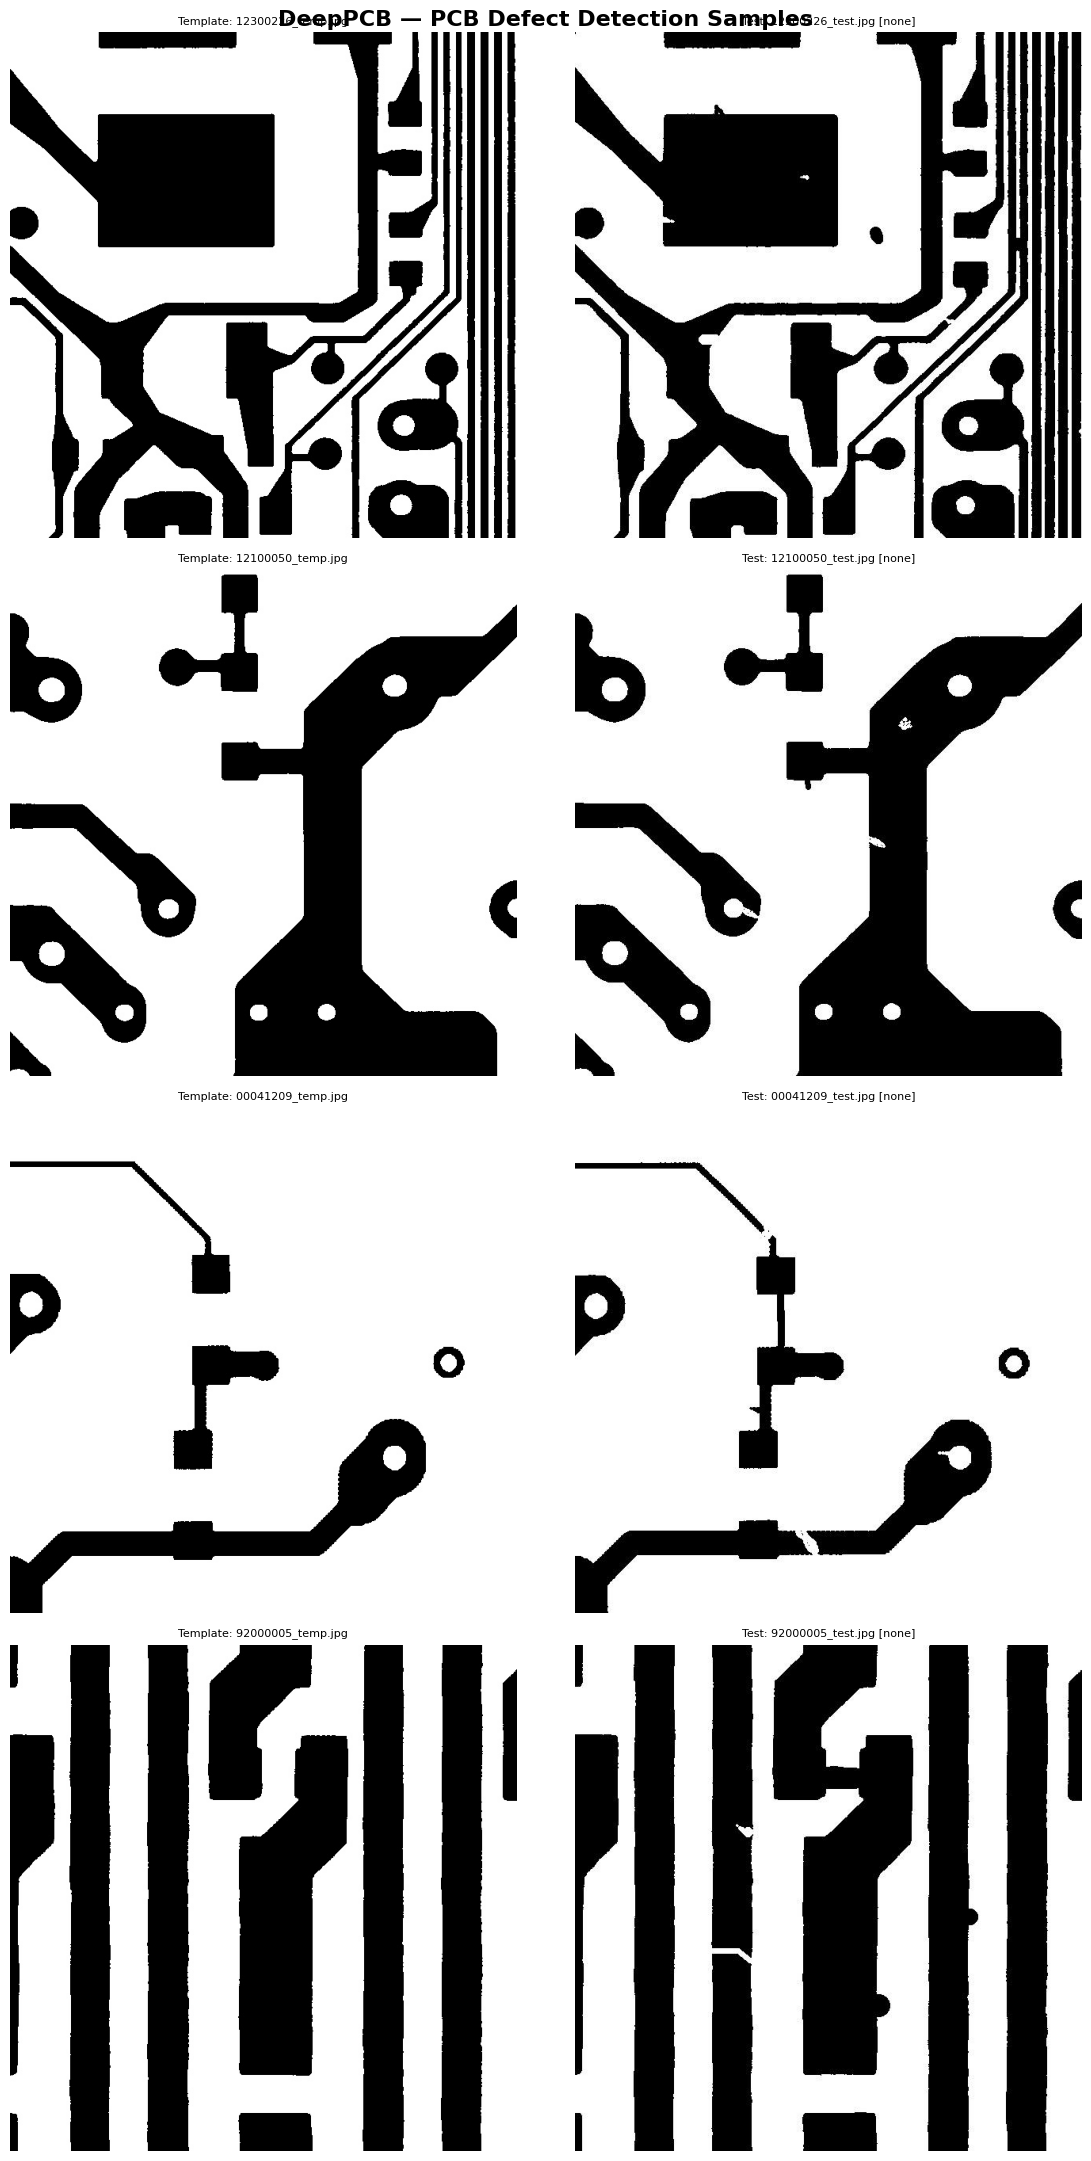

Defect type legend:
  1: open
  2: short
  3: mousebite
  4: spur
  5: copper
  6: pin-hole


In [3]:
# Read PCB images from the DeepPCB zip
pcb_zip_path = os.path.join(VOLUME_BASE, "deeppcb.zip")

defect_names = {1: 'open', 2: 'short', 3: 'mousebite', 4: 'spur', 5: 'copper', 6: 'pin-hole'}
defect_colors = {1: '#ff0000', 2: '#00ff00', 3: '#0088ff', 4: '#ffff00', 5: '#ff00ff', 6: '#00ffff'}

with zipfile.ZipFile(pcb_zip_path, 'r') as zf:
    test_images = sorted([f for f in zf.namelist() if f.endswith('_test.jpg')])

    print(f"Test images: {len(test_images)}")

    # Sample 4 pairs
    sample_tests = random.sample(test_images, min(4, len(test_images)))

    fig, axes = plt.subplots(4, 2, figsize=(12, 22))
    fig.suptitle("DeepPCB — PCB Defect Detection Samples", fontsize=16, fontweight='bold')
    cols = ["Template (reference)", "Test (with defects)"]
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=12, fontweight='bold')

    for idx, test_path in enumerate(sample_tests):
        # Load template image
        temp_path = test_path.replace('_test.jpg', '_temp.jpg')
        try:
            temp_data = zf.read(temp_path)
            temp_img = Image.open(io.BytesIO(temp_data))
            axes[idx][0].imshow(temp_img, cmap='gray')
        except Exception:
            axes[idx][0].text(0.5, 0.5, 'Template not found', ha='center', va='center')
        axes[idx][0].set_title(f"Template: {os.path.basename(temp_path)}", fontsize=8)
        axes[idx][0].axis('off')

        # Load test image with annotations
        test_data = zf.read(test_path)
        test_img = Image.open(io.BytesIO(test_data))
        axes[idx][1].imshow(test_img, cmap='gray')

        ann_path = test_path.replace('_test.jpg', '.txt')
        defects_found = []
        try:
            ann_data = zf.read(ann_path).decode('utf-8').strip()
            for line in ann_data.split('\n'):
                if line.strip():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        x1, y1, x2, y2, dtype = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4])
                        color = defect_colors.get(dtype, '#ffffff')
                        name = defect_names.get(dtype, f'type-{dtype}')
                        defects_found.append(name)
                        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                            linewidth=2, edgecolor=color, facecolor='none')
                        axes[idx][1].add_patch(rect)
                        axes[idx][1].text(x1, y1 - 3, name, color='white', fontsize=7,
                            fontweight='bold', bbox=dict(boxstyle='round,pad=0.2',
                            facecolor=color, alpha=0.8))
        except Exception:
            pass

        defect_str = ", ".join(defects_found) if defects_found else "none"
        axes[idx][1].set_title(f"Test: {os.path.basename(test_path)} [{defect_str}]", fontsize=8)
        axes[idx][1].axis('off')

    plt.tight_layout()
    plt.show()

# Print legend
print("Defect type legend:")
for k, v in defect_names.items():
    print(f"  {k}: {v}")

## 3. Corrosion Detection

HuggingFace Parquet dataset with embedded images and bounding box annotations.

- **Source:** [Francesco/corrosion-detection](https://huggingface.co/datasets/Francesco/corrosion-detection)
- **Licence:** CC BY 4.0
- **Size:** ~9,200 images

In [4]:
# Read corrosion data from parquet files
import glob

parquet_files = sorted(glob.glob(os.path.join(VOLUME_BASE, "*parquet")))
print(f"Parquet files found: {len(parquet_files)}")
for pf in parquet_files:
    print(f"  {os.path.basename(pf)} ({os.path.getsize(pf) / 1024 / 1024:.1f} MB)")

# Read the train parquet
train_pq = [f for f in parquet_files if 'train' in f]
if train_pq:
    df = pd.read_parquet(train_pq[0])
    print(f"\nTrain set rows: {len(df)}")
    print(f"Columns: {list(df.columns)}")

    # Show a sample row structure
    row = df.iloc[0]
    print(f"\nSample row keys: {list(row.index)}")
    if 'image' in df.columns:
        img_val = row['image']
        print(f"Image type: {type(img_val)}")
        if isinstance(img_val, dict):
            print(f"Image dict keys: {list(img_val.keys())}")
    if 'objects' in df.columns:
        obj_val = row['objects']
        print(f"Objects type: {type(obj_val)}")
        if isinstance(obj_val, dict):
            print(f"Objects dict keys: {list(obj_val.keys())}")

Parquet files found: 2
  test.parquet (16.3 MB)
  train.parquet (41.7 MB)



Train set rows: 840
Columns: ['image_id', 'image', 'width', 'height', 'objects']

Sample row keys: ['image_id', 'image', 'width', 'height', 'objects']
Image type: <class 'dict'>
Image dict keys: ['bytes', 'path']
Objects type: <class 'dict'>
Objects dict keys: ['id', 'area', 'bbox', 'category']


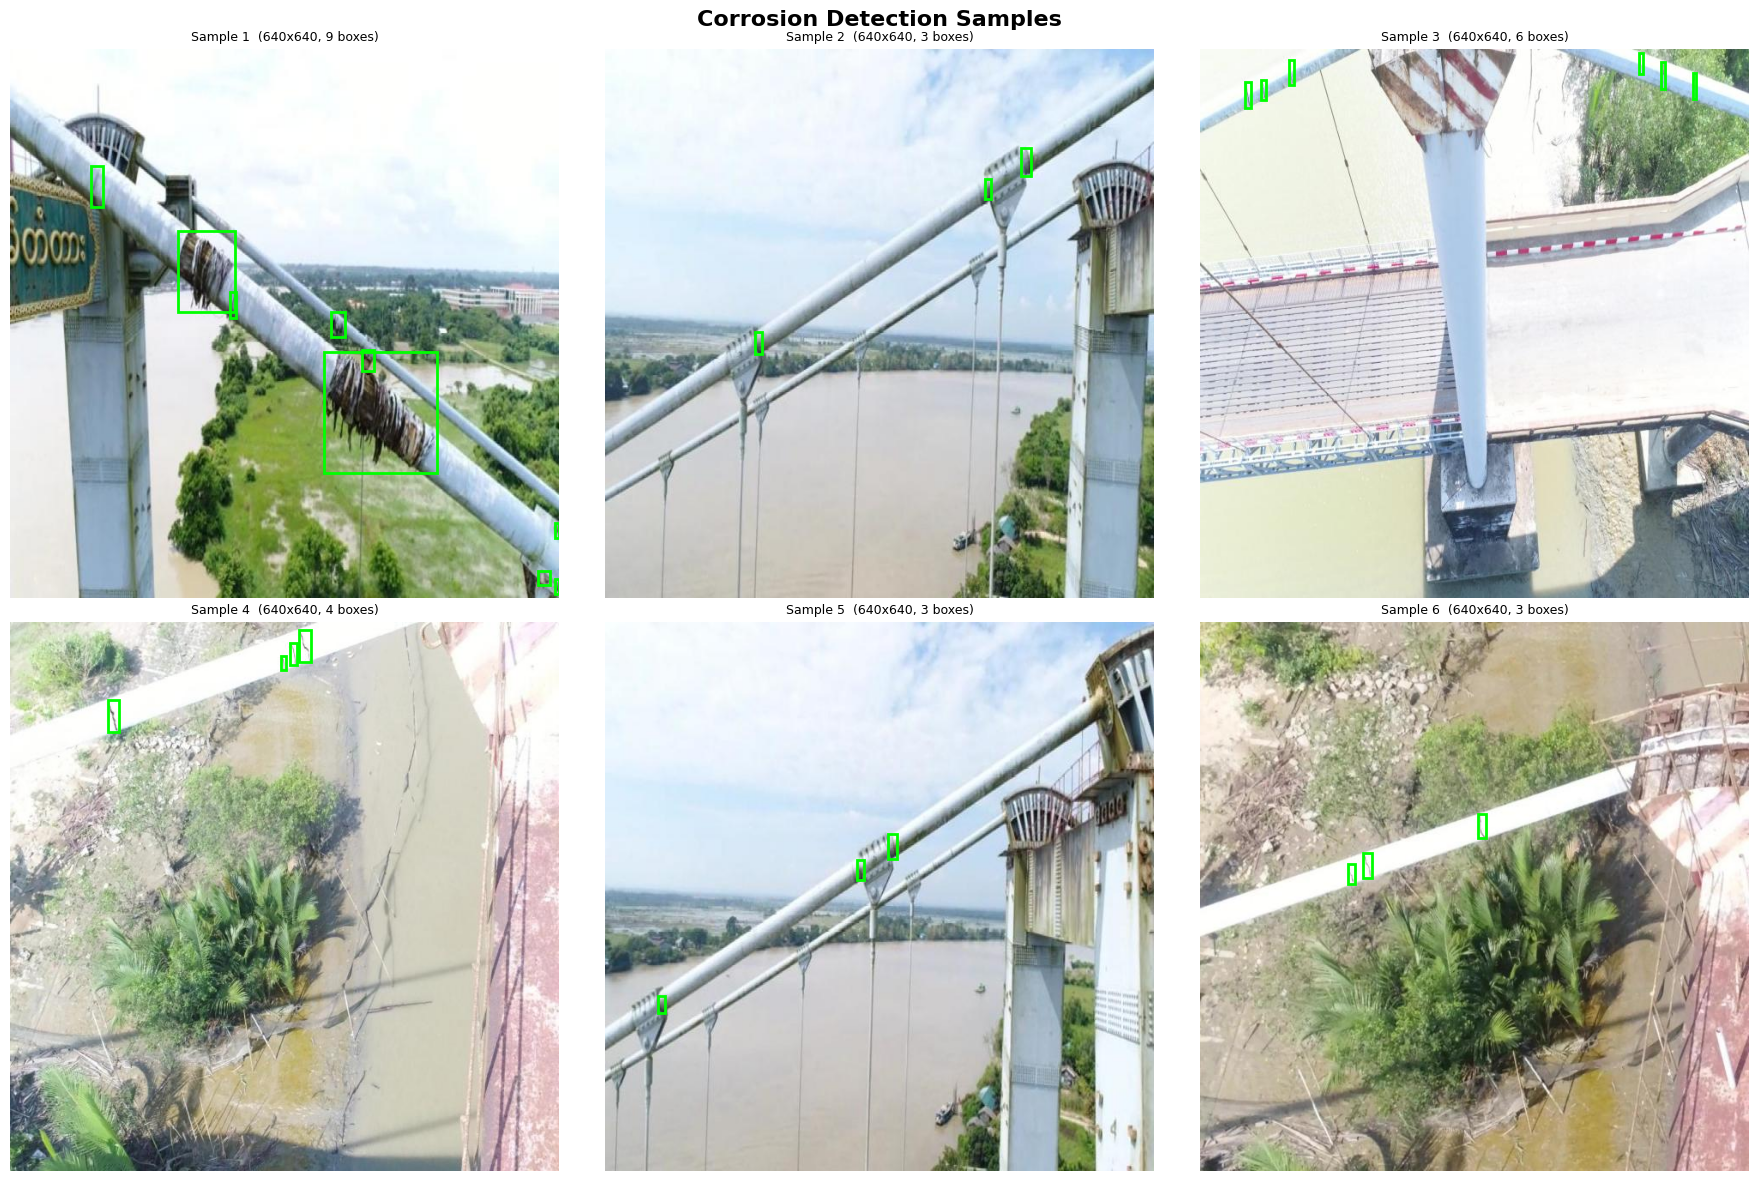

Showing 6 samples from 840 total training images
Green boxes = corrosion detections


In [5]:
# Visualise corrosion samples with bounding boxes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Corrosion Detection Samples", fontsize=16, fontweight='bold')

sample_df = df.sample(n=min(6, len(df)), random_state=42)

for idx, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[idx // 3][idx % 3]

    # Extract image
    img_data = row.get('image', {})
    img = None
    if isinstance(img_data, dict) and 'bytes' in img_data:
        img = Image.open(io.BytesIO(img_data['bytes']))
    elif isinstance(img_data, bytes):
        img = Image.open(io.BytesIO(img_data))

    if img is not None:
        ax.imshow(img)
        img_w, img_h = img.size

        # Draw bounding boxes
        objects = row.get('objects', {})
        bbox_count = 0
        if isinstance(objects, dict):
            bboxes = objects.get('bbox', [])
            categories = objects.get('category', [])

            for i, bbox in enumerate(bboxes):
                if len(bbox) == 4:
                    x, y, w, h = bbox
                    # If normalised (0-1), scale to pixel coords
                    if all(0 <= v <= 1.0 for v in [x, y, w, h]):
                        x, y, w, h = x * img_w, y * img_h, w * img_w, h * img_h

                    rect = patches.Rectangle((x, y), w, h,
                        linewidth=2, edgecolor='#00ff00', facecolor='none')
                    ax.add_patch(rect)
                    bbox_count += 1

        ax.set_title(f"Sample {idx + 1}  ({img_w}x{img_h}, {bbox_count} boxes)", fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Could not load image', ha='center', va='center')
        ax.set_title(f"Sample {idx + 1}", fontsize=9)

    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Showing {len(sample_df)} samples from {len(df)} total training images")
print("Green boxes = corrosion detections")

## Summary

| Dataset | Images | Classes | Format | Licence |
|---------|--------|---------|--------|---------|
| SHWD | ~7,581 | hat, person | Pascal VOC (XML + JPEG) | MIT |
| DeepPCB | ~1,500 pairs | 6 defect types | Image pairs + TXT | MIT |
| Corrosion | ~9,200 | corrosion | Parquet (embedded) | CC BY 4.0 |

All datasets are stored in the Databricks Unity Catalog volume:
`/Volumes/brian_gen_ai/cv_manufacturing/raw/`

To run this notebook on Databricks, update `VOLUME_BASE` in the Setup cell to the volume path and the zip/parquet file references to match the volume folder structure.